# 第 7 章　決策樹與隨機森林（Decision Tree & Random Forest）

「醫學生的機器學習入門」第 7 章配套 notebook。

- 建議在 **Google Colab** 執行：上方選單「執行階段 → 全部執行」即可，不需要另外安裝套件。
- 本機執行也可以（需要 numpy、pandas、matplotlib、scikit-learn）。
- 網站章節：請搭配網站「第 7 章　決策樹與隨機森林」的文字說明閱讀。
- 資料：UCI Heart Disease（Cleveland 子集，CC BY 4.0）；UCI Heart Failure Clinical Records（CC BY 4.0）。

> 本 notebook 的醫學資料皆為公開資料集的教學示範，**僅供學習，不構成臨床建議**。圖上標籤用英文，是因為 Colab 預設沒有中文字型。

## 0. 載入套件、印出版本

先確認套件版本。本 notebook 在 scikit-learn 1.6（Colab）與 1.9 都測試過。

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     StratifiedKFold, RepeatedStratifiedKFold)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 1. 讀入 Cleveland 心臟病資料

直接從 UCI 讀原始檔（沒有表頭、缺值寫成 `?`）。如果網路失敗，會改用 `ucimlrepo` 套件；兩者都失敗會印出清楚的錯誤訊息。

目標變數 `num` 原本是 0–4（血管攝影的狹窄程度等級），我們把 `num > 0` 當成「至少一條主要冠狀動脈狹窄 > 50%」＝ 1。

In [2]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
        "exang", "oldpeak", "slope", "ca", "thal", "num"]
try:
    df = pd.read_csv(URL, names=cols, na_values="?")
except Exception as e:
    print("直接下載失敗，改用 ucimlrepo：", e)
    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError:
        raise ImportError("請先執行 %pip install -q ucimlrepo 再重跑這格") from e
    r = fetch_ucirepo(id=45)
    df = r.data.features.join(r.data.targets)

print(df.shape)
print("遺漏值：", df.isna().sum()[df.isna().sum() > 0].to_dict())
df.head()

(303, 14)
遺漏值： {'ca': 4, 'thal': 2}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


只有 6 格遺漏（`ca` 4 格、`thal` 2 格），這裡直接刪掉那 6 列，剩 297 人。

In [3]:
df = df.dropna().reset_index(drop=True)
y = (df["num"] > 0).astype(int)
X = df.drop(columns="num")
print(X.shape, "有狹窄的比例：", round(y.mean(), 3))

(297, 13) 有狹窄的比例： 0.461


## 2. 切分訓練集／測試集

分類題一律 `stratify=y`，讓兩邊的有病比例一樣。決策樹**不需要標準化**。

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(207, 13) (90, 13)


## 3. 訓練一棵深度 3 的決策樹

`max_depth=3` 表示最多問三層問題。

In [5]:
tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree3.fit(X_train, y_train)
print("訓練集準確率：", round(tree3.score(X_train, y_train), 3))
print("測試集準確率：", round(tree3.score(X_test, y_test), 3))

訓練集準確率： 0.879
測試集準確率： 0.733


把樹畫出來。每個方框是一個節點：第一行是問題，`gini` 是不純度，`samples` 是走到這裡的人數，`value` 是 [無狹窄, 有狹窄] 的人數。

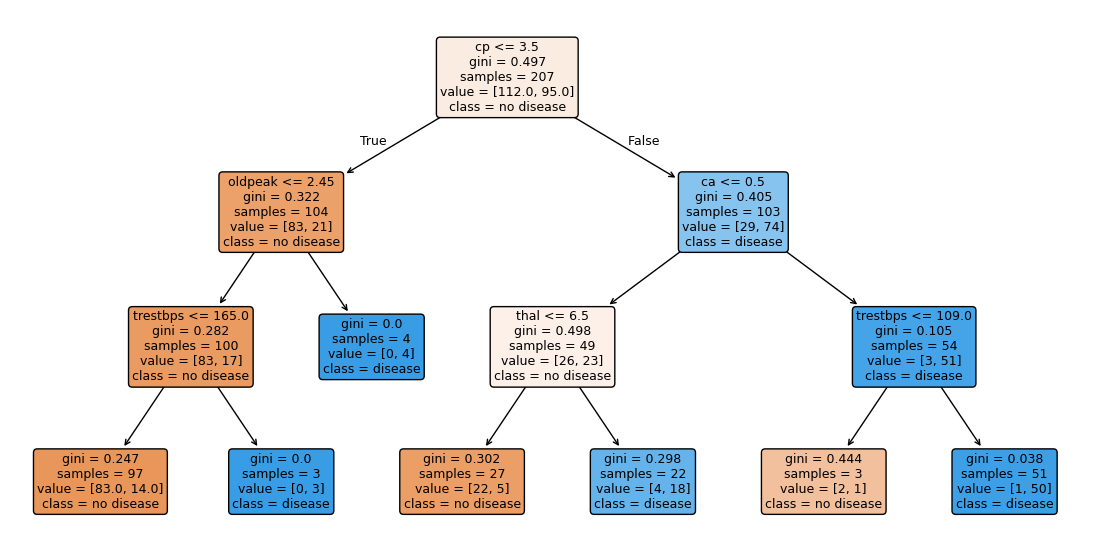

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tree3, feature_names=list(X.columns), class_names=["no disease", "disease"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.show()

也可以印成文字版的規則，很像臨床流程圖：

In [7]:
print(export_text(tree3, feature_names=list(X.columns)))

|--- cp <= 3.50
|   |--- oldpeak <= 2.45
|   |   |--- trestbps <= 165.00
|   |   |   |--- class: 0
|   |   |--- trestbps >  165.00
|   |   |   |--- class: 1
|   |--- oldpeak >  2.45
|   |   |--- class: 1
|--- cp >  3.50
|   |--- ca <= 0.50
|   |   |--- thal <= 6.50
|   |   |   |--- class: 0
|   |   |--- thal >  6.50
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- trestbps <= 109.00
|   |   |   |--- class: 0
|   |   |--- trestbps >  109.00
|   |   |   |--- class: 1



### 手算根節點的 Gini 不純度

根節點有 207 人，其中 112 人無狹窄、95 人有狹窄。Gini = 1 − (p₀² + p₁²)。

In [8]:
n0, n1 = (y_train == 0).sum(), (y_train == 1).sum()
p0, p1 = n0 / (n0 + n1), n1 / (n0 + n1)
print("手算 Gini =", round(1 - (p0**2 + p1**2), 3))
print("樹裡記錄的 Gini =", round(tree3.tree_.impurity[0], 3))

手算 Gini = 0.497
樹裡記錄的 Gini = 0.497


## 4. 故意做錯：不限深度的樹

不設 `max_depth`，樹會一直切到每片葉子都純為止。用 5 折 × 5 次的交叉驗證，比較各深度的訓練分數與驗證分數。

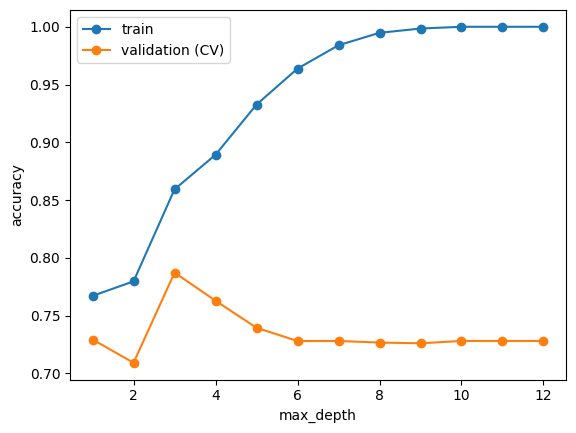

驗證分數最高的深度： 3


In [9]:
depths = range(1, 13)
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
train_acc, val_acc = [], []
for d in depths:
    res = cross_validate(DecisionTreeClassifier(max_depth=d, random_state=42), X, y,
                         cv=cv_rep, return_train_score=True)
    train_acc.append(res["train_score"].mean())
    val_acc.append(res["test_score"].mean())

plt.plot(depths, train_acc, "o-", label="train")
plt.plot(depths, val_acc, "o-", label="validation (CV)")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.show()
print("驗證分數最高的深度：", list(depths)[int(np.argmax(val_acc))])

深度愈大，訓練分數逼近 100%，驗證分數卻在深度 3 左右就到頂，之後下滑——這就是過擬合（overfitting）。

## 5. 剪枝：用 `ccp_alpha` 讓樹變簡單

`ccp_alpha`（cost-complexity pruning）愈大，樹被剪得愈多。先讓 sklearn 算出所有候選 alpha，再用交叉驗證挑最好的。

In [10]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]          # 最後一個 alpha 會剪到只剩根節點，排除
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = [cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=42),
                          X_train, y_train, cv=cv5).mean() for a in alphas]
best_alpha = alphas[int(np.argmax(scores))]
pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42).fit(X_train, y_train)
print("最佳 ccp_alpha =", round(best_alpha, 4))
print("剪枝後葉子數：", pruned.get_n_leaves(), "（不剪：",
      DecisionTreeClassifier(random_state=42).fit(X_train, y_train).get_n_leaves(), "）")
print("剪枝後測試集準確率：", round(pruned.score(X_test, y_test), 3))

最佳 ccp_alpha = 0.0115
剪枝後葉子數： 11 （不剪： 32 ）
剪枝後測試集準確率： 0.744


## 6. 隨機森林：很多棵樹投票

`n_estimators=300` 棵樹，每棵用不同的 bootstrap 樣本、每次切分只看部分特徵（預設 `max_features="sqrt"`）。`oob_score=True` 會順便算出袋外（OOB）準確率。

In [11]:
rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("訓練集準確率：", round(rf.score(X_train, y_train), 3))
print("OOB 準確率：  ", round(rf.oob_score_, 3))
print("測試集準確率：", round(rf.score(X_test, y_test), 3))

tn, fp, fn, tp = confusion_matrix(y_test, rf.predict(X_test)).ravel()
print(f"測試集敏感度 = {tp / (tp + fn):.3f}，特異度 = {tn / (tn + fp):.3f}")

訓練集準確率： 1.0
OOB 準確率：   0.826
測試集準確率： 0.833
測試集敏感度 = 0.762，特異度 = 0.896


測試集只有 90 人，單次切分的分數會晃。用同一組 5 折交叉驗證公平比較三個模型：

In [12]:
models = {
    "tree (no limit)": DecisionTreeClassifier(random_state=42),
    "tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=cv5)
    print(f"{name:16s} 平均準確率 {s.mean():.3f}（各折標準差 {s.std():.3f}）")

tree (no limit)  平均準確率 0.721（各折標準差 0.027）
tree (depth 3)   平均準確率 0.788（各折標準差 0.054）


random forest    平均準確率 0.815（各折標準差 0.056）


### 樹要種幾棵？看 OOB 分數隨樹數的變化

樹很少時，有些病人剛好每棵樹都抽到、沒有 OOB 票，sklearn 會發出提醒，這裡先把該提醒關掉。

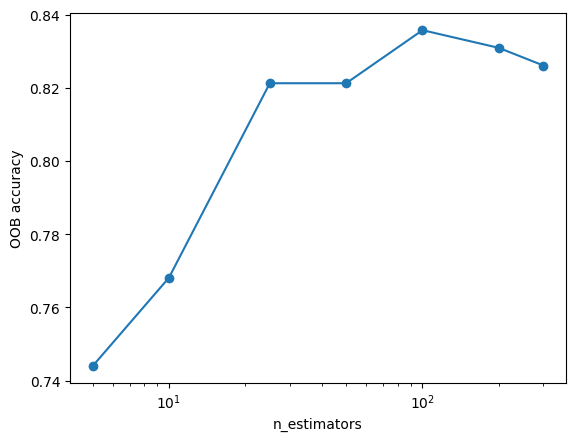

In [13]:
n_list = [5, 10, 25, 50, 100, 200, 300]
oob = []
for n in n_list:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)   # "Some inputs do not have OOB scores"
        m = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
        m.fit(X_train, y_train)
    oob.append(m.oob_score_)
plt.plot(n_list, oob, "o-"); plt.xscale("log")
plt.xlabel("n_estimators"); plt.ylabel("OOB accuracy"); plt.show()

## 7. 特徵重要性：不純度 vs 排列

我們故意加一欄**純雜訊** `random_id`（0–999 的隨機整數，跟心臟病毫無關係），看兩種重要性怎麼排它。
為了不被單一測試集的運氣左右，用 5 折交叉驗證，每折都在「沒參與訓練」的那一折上算排列重要性，最後取平均。

In [14]:
rng = np.random.default_rng(42)
X_noise = X.copy()
X_noise["random_id"] = rng.integers(0, 1000, len(X_noise))

imps, perms = [], []
for tr, te in cv5.split(X_noise, y):
    m = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    m.fit(X_noise.iloc[tr], y.iloc[tr])
    imps.append(m.feature_importances_)
    pi = permutation_importance(m, X_noise.iloc[te], y.iloc[te], n_repeats=10,
                                random_state=42, n_jobs=-1)
    perms.append(pi.importances_mean)

imp_table = pd.DataFrame({"impurity": np.mean(imps, axis=0),
                          "permutation": np.mean(perms, axis=0)}, index=X_noise.columns)
imp_table["rank_impurity"] = imp_table["impurity"].rank(ascending=False).astype(int)
imp_table["rank_permutation"] = imp_table["permutation"].rank(ascending=False).astype(int)
imp_table.sort_values("impurity", ascending=False).round(3)

,impurity,permutation,rank_impurity,rank_permutation
thal,0.117,0.037,1,2
ca,0.116,0.050,2,1
cp,0.114,0.019,3,3
thalach,0.109,0.005,4,8
oldpeak,0.104,0.017,5,4
random_id,0.083,-0.003,6,13
age,0.080,-0.002,7,12
chol,0.067,0.005,8,9
trestbps,0.062,0.006,9,7
exang,0.046,0.014,10,5


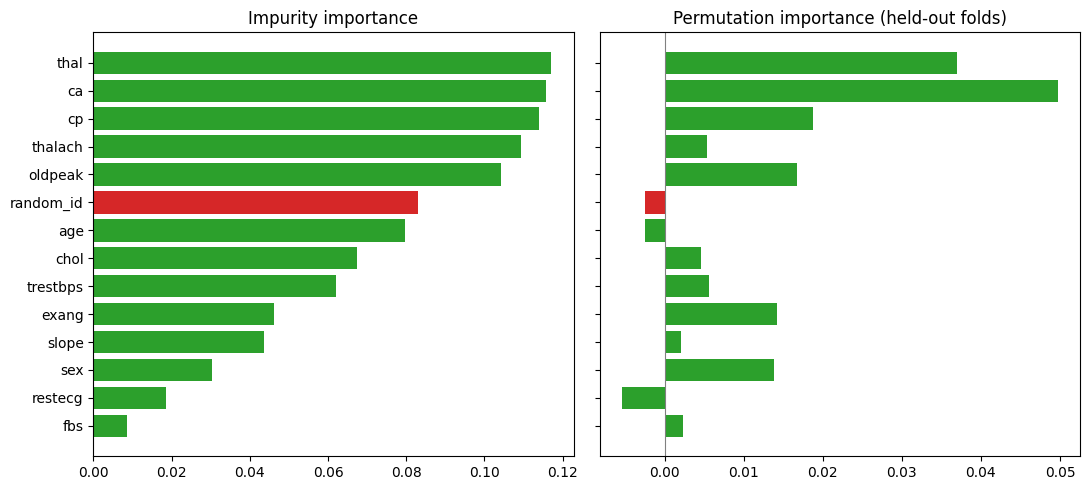

In [15]:
order = imp_table.sort_values("impurity").index
colors = ["tab:red" if c == "random_id" else "tab:green" for c in order]
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
axes[0].barh(order, imp_table.loc[order, "impurity"], color=colors)
axes[0].set_title("Impurity importance")
axes[1].barh(order, imp_table.loc[order, "permutation"], color=colors)
axes[1].axvline(0, color="grey", lw=0.8)
axes[1].set_title("Permutation importance (held-out folds)")
plt.tight_layout(); plt.show()

雜訊欄在「不純度重要性」排到中段，因為它有 1000 種可能數值、樹總能找到切點把訓練資料切得更純；
在「排列重要性」則約等於 0——打亂它，模型在沒看過的病人身上並沒有變差。

**記得**：重要性只代表「模型預測時用得多」，不代表因果，也不代表臨床上重要。

## 8. 備選資料：心衰竭資料的 `time` 洩漏

Heart Failure Clinical Records（299 人）有一欄 `time`＝追蹤天數。死亡的病人追蹤期自然比較短，所以 `time` 是**結果發生後才知道的資訊**，放進模型就是資料洩漏（data leakage）。

In [16]:
HF_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/00519/"
          "heart_failure_clinical_records_dataset.csv")
try:
    hf = pd.read_csv(HF_URL)
except Exception as e:
    raise RuntimeError("下載心衰竭資料失敗，請確認網路；或改用 ucimlrepo 的 fetch_ucirepo(id=519)") from e

y_hf = hf["DEATH_EVENT"]
for label, drop_cols in [("with time (leak)", ["DEATH_EVENT"]),
                         ("without time", ["DEATH_EVENT", "time"])]:
    X_hf = hf.drop(columns=drop_cols)
    auc = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                          X_hf, y_hf, cv=cv5, scoring="roc_auc")
    print(f"{label:17s} 5 折平均 AUC = {auc.mean():.3f}")

with time (leak)  5 折平均 AUC = 0.904


without time      5 折平均 AUC = 0.775


有 `time` 的 AUC 看起來漂亮很多，但那是作弊來的：真正要做預測的那一刻，你不可能知道病人之後會被追蹤多久。

## 動手試試

1. 把第 3 節的 `max_depth=3` 改成 `2`、`5`、`None`，重畫樹，觀察葉子數與測試集準確率怎麼變。
2. 在第 6 節把 `max_features` 改成 `None`（每次切分看全部特徵，就變成單純的 bagging），比較 OOB 分數。
3. 在第 7 節再加一欄 `rng.integers(0, 2, len(X_noise))`（只有 0/1 兩種值的雜訊），它的不純度重要性會比 `random_id` 高還是低？為什麼？